# **Business Understanding**

Description:
A simple yet challenging project, to predict the housing price based on certain factors like house area, bedrooms, furnished, nearness to mainroad, etc. The dataset is small yet, it's complexity arises due to the fact that it has strong multicollinearity. Can you overcome these obstacles & build a decent predictive model?

Acknowledgement:
Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102. Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.

[housing-prices-dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)


#### **Load DataSet**

In [11]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn import linear_model

# **Data Undestanding** 
- head and tail (printing out the first 5 or few entries and the last entries)
- shape (dimensions)
- columns
- datatypes
- info
- duplicates
- null value check
- describe numerical (descriptive)
- describe categroical 

In [1]:
class DataUnderstanding:
    def getGlimpseodData(df):
        display(df.head())
        display(df.tail())

    def getDimensions(df):
        records, features = df.shape
        output = f"The data set has {records} records and {features} features"
        print(output)

    def infoDatatype(df):
        dipslay(df.info())
        display(df.dtypes)

    def checkShallowIntegrity(df):
        display(df.isna().sum())
        display(df.duplicated().sum())

    def descriptiveStatsQuantitative(df):
        display(df.describe())

    def descriptiveStatsQualitative(df):
        display(df.describe(include='object'))

#### **Load Data**

In [4]:
df = pd.read_csv("data/Housing.csv")

In [8]:
df.shape

(545, 13)

In [5]:
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished


In [7]:
new_df = df[['price','area']]
new_df.head()

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


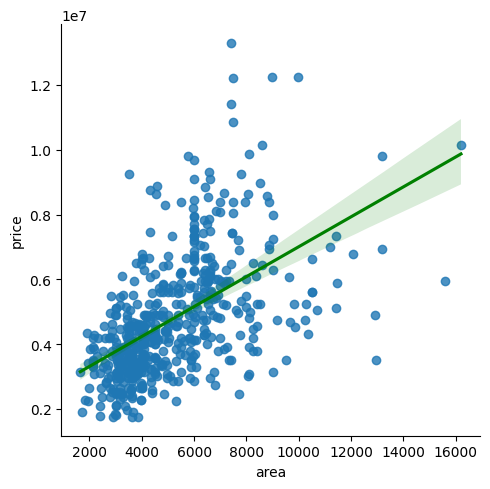

In [10]:
sns.lmplot(data=new_df, x="area", y="price", line_kws={'color': 'green'} ) 
plt.show()

In [16]:
display(df.isna().sum())
display(df.duplicated().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

np.int64(0)

In [19]:
df['area'].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

In [17]:
reg = linear_model.LinearRegression() # getting an instance of the linear model 
reg.fit(df[['area']], df['price']) # df[['area']] = > is independent variable while df['price] => dependent variable(target variable)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# getting the price of house with a 1650 square feet measurement
df.loc[df['area'] == 1650]


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
449,3150000,1650,3,1,2,no,no,yes,no,no,0,no,unfurnished


In [21]:
reg.predict([[1650]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3149567.05794652])

In [22]:
reg.predict([[1651]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3150029.0328408])

In [23]:
reg.predict([[1652]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3150491.00773507])

In [24]:
reg.predict([[165100]])

/home/josephridge/Desktop/Desktop/DSA_case_study_1/env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([78659363.52683297])

In [28]:
reg.coef_ # B1

array([461.97489427])

In [29]:
reg.intercept_  # Bo

np.float64(2387308.48239643)

In [30]:
# y = mx + c
2387308.48239643 + (461.97489427*165100)

78659363.52637342